<a href="https://colab.research.google.com/github/Maryam-Skaik/rfm-customer-segmentation-kmeans/blob/main/notebook/rfm_customer_segmentation_kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Clustering

## Imports

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
fpath = '/content/drive/MyDrive/AXSOSACADEMY/03-MachineLearning/Week10/Data/rfm.csv'
df = pd.read_csv(fpath)
df.head()

,CustomerID,Recency,Frequency,MonetaryValue
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


- CustomerID, Recency, Frequency, and MonetaryValue represent key metrics for understanding customer behavior

- Recency indicates how recently a customer made a purchase

- Frequency shows how often a customer purchases within a period

- MonetaryValue reflects the total spending of a customer

- These metrics are used to segment customers for targeted marketing and retention strategies

In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     4338 non-null   int64  
 1   Recency        4338 non-null   int64  
 2   Frequency      4338 non-null   int64  
 3   MonetaryValue  4338 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 135.7 KB


- The dataset contains 4338 customers

- All columns (CustomerID, Recency, Frequency, MonetaryValue) have no missing values

- Recency, Frequency, and CustomerID are integers; MonetaryValue is a float

In [5]:
df = df.drop(columns=['CustomerID'])
df.head()

,Recency,Frequency,MonetaryValue
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


## Scaling and Modeling


In [6]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
X_scaled.head()

,Recency,Frequency,MonetaryValue
0,2.334574,-0.425097,8.358668
1,-0.905340,0.354417,0.250966
2,-0.175360,-0.035340,-0.028596
3,-0.735345,-0.425097,-0.033012
4,2.174578,-0.425097,-0.191347


## Choosing Best K (Clustering Quality)

In [7]:
ks = range(2,11)
sils = []
inertias = []

for k in ks:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(X_scaled)

    sils.append(silhouette_score(X_scaled, kmeans.labels_))
    inertias.append(kmeans.inertia_)

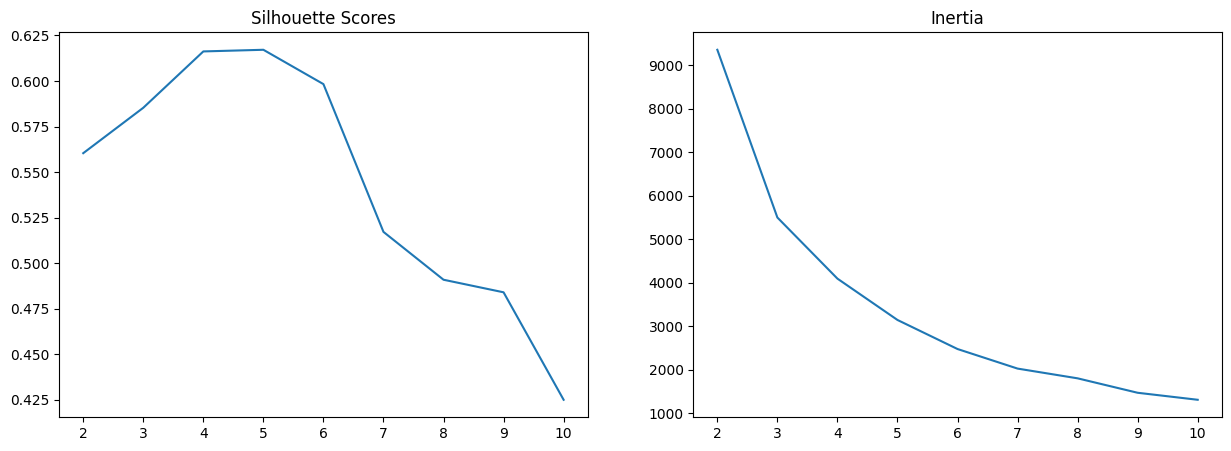

In [8]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

axes[0].plot(ks, sils)
axes[0].set_title('Silhouette Scores')
axes[0].set_xticks(ks);

axes[1].plot(ks, inertias)
axes[1].set_title('Inertia')
axes[1].set_xticks(ks);

## Train Final Model

In [9]:
kmeans = KMeans(n_clusters=4, n_init='auto', random_state=42)
kmeans.fit(X_scaled)

KMeans(n_clusters=4, random_state=42)

- We scaled the Recency, Frequency, and MonetaryValue features to ensure equal contribution to clustering

- Used the Elbow Method (inertia) and Silhouette Scores to find the optimal number of clusters

- Plotted both metrics to visually identify the best k

- Fitted the k-means model with k=4 and assigned clusters to each customer

In [10]:
df['cluster'] = kmeans.labels_
df.head()

,Recency,Frequency,MonetaryValue,cluster
0,326,1,77183.60,3
1,2,7,4310.00,0
2,75,4,1797.24,0
3,19,1,1757.55,0
4,310,1,334.40,1


## Group By Cluster

In [12]:
cluster_groups = df.groupby('cluster', as_index=False).mean()

cluster_profile = df.groupby('cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'MonetaryValue': 'mean',
    'cluster': 'count'
}).rename(columns={'cluster': 'Customer_Count'}).round(1)

print(cluster_profile)

         Recency  Frequency  MonetaryValue  Customer_Count
cluster                                                   
0           43.7        3.7         1359.0            3054
1          248.1        1.6          480.6            1067
2            7.4       82.5       127338.3              13
3           15.5       22.3        12709.1             204


## Visualizing Cluster Means

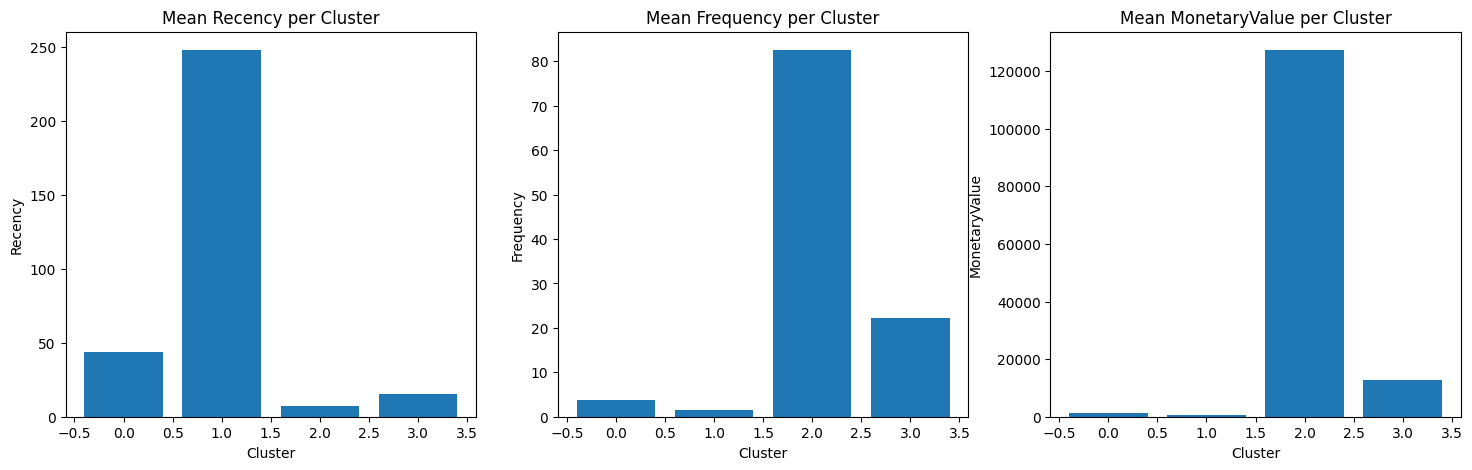

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1 row, 3 columns
for i, col in enumerate(['Recency', 'Frequency', 'MonetaryValue']):
    axes[i].bar(cluster_groups['cluster'], cluster_groups[col])
    axes[i].set_title(f'Mean {col} per Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(col)

* **Cluster 2:** Small group of VIP customers who purchase very frequently and contribute the highest revenue

* **Cluster 0:** Largest customer segment with low purchase frequency and relatively low spending

* **Cluster 1:** Inactive customers with very high recency, indicating possible customer churn

* **Cluster 3:** Recently active customers with strong growth potential and moderate-to-high spending

* Purchase frequency and customer spending had the strongest influence on the clustering results, while recency helped identify inactive and highly engaged customers

## Customer Segmentation & Marketing Strategy

* **Cluster 0 — Low-Value Customers**

  * Represents the largest customer group with low purchase frequency and relatively low spending
  * Although individual value is low, the large customer count makes this segment important for overall business growth
  * Strategy: Use low-cost promotions, bundle offers, and personalized recommendations to increase repeat purchases and engagement

* **Cluster 1 — Inactive Customers**

  * Customers with very high recency, meaning they have not purchased for a long period and show low engagement
  * This segment has a high risk of customer churn
  * Strategy: Run reactivation campaigns such as reminder emails, return discounts, and personalized “we miss you” offers to recover customer activity

* **Cluster 2 — VIP Customers**

  * Smallest customer segment, but contributes the highest revenue with extremely high purchase frequency and spending
  * These customers are the most valuable to the business and critical for long-term profitability
  * Strategy: Focus on loyalty programs, exclusive deals, premium support, early access, and personalized rewards to maximize retention and customer lifetime value

* **Cluster 3 — Potential Loyal Customers**

  * Recently active customers with strong spending behavior and clear growth potential
  * This segment could develop into future VIP customers with proper engagement
  * Strategy: Encourage upselling, cross-selling, and personalized engagement campaigns to increase customer value and strengthen loyalty

* Overall, clustering helps businesses better understand customer behavior and allocate marketing efforts more effectively, leading to improved customer retention, smarter decision-making, and higher revenue efficiency